In [1]:
from transformers import PreTrainedModel
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
import torch.nn.functional as F
from transformers import PretrainedConfig
# from transformers import ASTConfig
from transformers import ASTModel, ASTConfig
ast_base = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

c:\Users\Marina\genres\beat_venv_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Marina\genres\beat_venv_new\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [2]:
import numpy as np

data_fma = np.load(r"data\fma_test_unsorted_new.npz")
lst = data_fma.files
genres = [file.split("___")[0] for file in lst]
genres[:2]

['Electronic', 'Electronic']

In [3]:
class ASTGenreConfig(ASTConfig):
    model_type= "ast-genre_classification"
    def __init__(self, **kwargs):   # **kwargs: arbitrary number of key words arguments
        super().__init__(**kwargs)
        self.num_labels =kwargs.get("num_labels", 13)
        self.dropouts = kwargs.get("dropouts", 0.2)
        self.learning_rate = kwargs.get("learning_rate",3e-5 )
        self.freeze_layers = kwargs.get("freeze_layers", None)
        self.dropout_top = kwargs.get("dropout_top", 0)


class ASTForGenreClassification(PreTrainedModel):
    config_class = ASTGenreConfig

    def __init__(self, config, ast_model=ast_base):
        super().__init__(config)
        self.ast = ast_model
        self.dropout = nn.Dropout(config.dropout_top)
        self.activation_fn = self.get_activation(config.activation_fn)
        self.freeze_layers = config.freeze_layers
        self.classifier = nn.Linear(768, config.num_labels)
        self.normalisation = self.get_normalisation(config.normalisation, 768)
        if self.freeze_layers:
            print(f"freezing {self.freeze_layers} layers")
            for i, layer in enumerate(self.ast.encoder.layer):
                if i < self.freeze_layers:
                    for param in layer.parameters():
                        param.requires_grad = False
        

    def get_activation(self, activation_fn) -> nn.Module:
        acrivation_mapping = {
        "relu":  nn.ReLU(),
        "gelu":  nn.GELU(),
        "none":  nn.Identity(),
    }
        return acrivation_mapping.get(activation_fn)
    def get_normalisation(self, norm_type, dim) -> nn.Module:
        norm_mapping = {
        "layer": lambda d: nn.LayerNorm(d),
        "none": lambda d: nn.Identity(),
    }
        return norm_mapping.get(norm_type, lambda d: nn.Identity())(dim)
    def forward(self, input_values, labels=None):
        x = self.ast.embeddings(input_values)
        x = self.ast.encoder(x).last_hidden_state
        x = self.normalisation(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        x = self.activation_fn(x)
        logits = self.classifier(x)
        assert labels.max() < logits.shape[1], f"Invalid label {labels.max()} for {logits.shape[1]} classes"
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels, label_smoothing=0.1)
        return SequenceClassifierOutput(loss=loss, logits=logits)

In [4]:
import os
os.environ["HF_TOKEN"] = ""
model = ASTForGenreClassification.from_pretrained("PolinaKozarovytska/ast_merge", revision="75ebd2b77530cbc89d47f7b4cc773e229d5944f1")
model.eval()  # set to evaluation mode


freezing 4 layers


ASTForGenreClassification(
  (ast): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=7

In [5]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                  Param #
ASTForGenreClassification                               --
├─ASTModel: 1-1                                         --
│    └─ASTEmbeddings: 2-1                               933,888
│    │    └─ASTPatchEmbeddings: 3-1                     197,376
│    │    └─Dropout: 3-2                                --
│    └─ASTEncoder: 2-2                                  --
│    │    └─ModuleList: 3-3                             85,054,464
│    └─LayerNorm: 2-3                                   1,536
├─Dropout: 1-2                                          --
├─Identity: 1-3                                         --
├─Linear: 1-4                                           9,997
├─Identity: 1-5                                         --
Total params: 86,197,261
Trainable params: 57,845,773
Non-trainable params: 28,351,488

In [6]:
def prepare_data(data):
    all_keys = data.files
    X = []
    y = []
    for key in all_keys:
        genre = key.split("/")[0]
        if not genre.startswith("Experimental"):
            X.append(data[key])
            y.append(genre)
    return X,y
X,y = prepare_data(data_fma)
print(len(y))

700


In [7]:
from tqdm import tqdm
import torch
target_time = 1020
def get_embeddings(X, y):
    spectrograms = {}
    target_time = 1020
    for i in tqdm(range(len(y))):
        spec = X[i]
        label = y[i]
        # if spec.shape[0] > target_time:
        #     spec = spec[:target_time, :]
        if spec.shape[0] > target_time:
            start = (spec.shape[0] - target_time) // 2
            spec = spec[start: start + target_time, :]
        spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
        try:
            with torch.no_grad():
                patches = model.ast.embeddings(spec)
                encoder_outputs = model.ast.encoder(patches, output_hidden_states=True)
                hidden_states = encoder_outputs.hidden_states  
                #using pre-last layer 
                pre_last = hidden_states[-1]              # shape: (1, num_patches, hidden_dim)
                embedding = pre_last.mean(dim=1) 
                #outputs = model.ast.encoder(patches, output_hidden_states=True)
                #last_hidden = outputs.last_hidden_state  # (1, num_patches, hidden_dim)
                #embedding= last_hidden.mean(dim = 1)
                spectrograms[label] = embedding
        except Exception as e:
            print(f"problem with the file {lst[i]}")
            print(e)
    return spectrograms
spectrograms = get_embeddings(X,y)

100%|██████████| 700/700 [22:11<00:00,  1.90s/it]


In [8]:
spectrograms.keys()

dict_keys(['Electronic___all_india_radio___lucky', 'Electronic___ample_mammal___the_atmosphere', 'Electronic___anima___gli_spiriti', 'Electronic___anima___overlooking_eternity', 'Electronic___azureflux___boss_ass_bits', 'Electronic___beat_doctor___too_retro', 'Electronic___beatoven___wanna_see_my_spaceship', 'Electronic___black_era___then', 'Electronic___blasterhead___skyblue_monday', 'Electronic___broke_for_free___like_swimming', 'Electronic___broke_for_free___one_and', 'Electronic___büromaschinen___forecast', 'Electronic___candlegravity___a_lifetime_of_summers_past', 'Electronic___chibibo___phantasm', 'Electronic___christian_bjoerklund___5', 'Electronic___csum___shouldve_been_a_hidden_track', 'Electronic___dan_lizard___the_look_in_your_eyes', 'Electronic___decktonic___this_modem_life', 'Electronic___digi_galessio___camuffarsi_e_mantenere_la_calma_al_pianobar', 'Electronic___digi_galessio___switches_instrumetal', 'Electronic___dokashiteru___our_slanted_voices_ft_colin_mutchler', 'Elec

In [9]:
spectrograms_np = torch.stack([v.squeeze(0) for v in spectrograms.values()]).numpy()
spectrograms_np.shape

(700, 768)

In [10]:
true_labels = [i.split("___")[0]  for i in spectrograms.keys()]
true_labels[0]

'Electronic'

In [12]:
import collections
c = collections.Counter(true_labels)
c

Counter({'Electronic': 100,
         'Folk': 100,
         'Hip-Hop': 100,
         'Instrumental': 100,
         'International': 100,
         'Pop': 100,
         'Rock': 100})

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_labels_enc = le.fit_transform(true_labels)
label_names = le.classes_

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
spectrograms_scaled = scaler.fit_transform(spectrograms_np)

In [136]:
from sklearn.decomposition import PCA
reduction = "pca"
pca = PCA(n_components=200)
spectrograms_reduced = pca.fit_transform(spectrograms_scaled)
spectrograms_reduced.shape

(699, 200)

In [15]:
import umap.umap_ as umap   # need to install umap-learn
reduction = "umap"
reducer = umap.UMAP(n_components =200)
spectrograms_reduced = reducer.fit_transform(spectrograms_scaled)
spectrograms_reduced.shape

(699, 200)

In [285]:
from sklearn.manifold import Isomap
reduction = "isomap"
embedding = Isomap(n_components=200)
spectrograms_reduced= embedding.fit_transform(spectrograms_scaled)
spectrograms_reduced.shape

(699, 200)

In [68]:
from sklearn.manifold import TSNE
spectrograms_reduced = TSNE(n_components=2, perplexity=90, random_state=42).fit_transform(spectrograms_scaled) # 2, 50 taken from paper moura2023use

In [305]:
from sklearn.manifold import MDS
reduction = "mds"
embedding = MDS(n_components=200, n_init=10)
spectrograms_reduced= embedding.fit_transform(spectrograms_scaled)
spectrograms_reduced.shape

(699, 200)

In [95]:
from sklearn.cluster  import KMeans
algorithm = "KMeans"
kmeans = KMeans(n_clusters = 7).fit(spectrograms_reduced)
predicted_labels =kmeans.labels_

In [150]:
collections.Counter(kmeans.labels_)

Counter({np.int32(2): 158,
         np.int32(4): 136,
         np.int32(5): 119,
         np.int32(0): 92,
         np.int32(3): 91,
         np.int32(1): 54,
         np.int32(6): 49})

In [341]:
from sklearn.cluster import SpectralClustering
algorithm = "spectral"
spectral = SpectralClustering(n_clusters=7,
        assign_labels='discretize',
          
        random_state=42).fit(spectrograms_reduced)
predicted_labels = spectral.labels_

In [103]:
from sklearn.cluster import MeanShift
algorithm = "mean shift"
mean_shift = MeanShift(bandwidth = 10).fit(spectrograms_reduced)
predicted_labels= mean_shift.labels_

In [336]:
from sklearn.mixture import GaussianMixture
algorithm = "gm"
gm = GaussianMixture(n_components=7,  covariance_type="full",
    reg_covar=1e-3, ).fit(spectrograms_reduced)
predicted_labels = gm.predict(spectrograms_reduced)

In [137]:
from sklearn.cluster import DBSCAN
algorithm = "DBSCAN"
dbscan = DBSCAN(eps=1, min_samples=70).fit(spectrograms_reduced)
predicted_labels = dbscan.labels_

In [69]:
from sklearn.cluster import HDBSCAN
algorithm = "HDBSCAN"
hdbscan = HDBSCAN(min_cluster_size =25, max_cluster_size= 120).fit(spectrograms_reduced)  # 15, 120 -> 40.92%
predicted_labels = hdbscan.labels_ +1 
max(predicted_labels)

6

In [317]:
n_clusters = len(set(predicted_labels)) - (1 if -1 in predicted_labels else 0)
n_noise = list(predicted_labels).count(-1)

print(f"result by {algorithm}")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

result by HDBSCAN
Number of clusters: 6
Number of noise points: 0


In [102]:
mapping = greedy_cluster_mapping(true_labels_enc, predicted_labels)
aligned_predicted_labels = np.array([mapping[label] for label in predicted_labels])
accuracy = (aligned_predicted_labels == true_labels_enc).mean()
print(f"{algorithm} Accuracy (after best match) with {reduction}: {accuracy:.2%}")

Agglomerative Accuracy (after best match) with t-SNE: 40.77%


In [101]:
from sklearn.cluster import AgglomerativeClustering
algorithm = "Agglomerative"
agglomerative = AgglomerativeClustering(n_clusters=7, linkage = "complete").fit(spectrograms_reduced)
predicted_labels = agglomerative.labels_

# Grid search for different algorithms

In [48]:
import pandas as pd
def get_df_average(df, algorithms_names, reduction_names, style= "stat"):
    df_averages = pd.DataFrame(index=algorithms_names, columns=reduction_names) 
    for reduction in reduction_names:
            for algorithm in algorithms_names:
                scores = np.array(df.at[algorithm, reduction], dtype=float)
                mean = "{:.2f}".format(np.mean(scores))
                var ="{:.2f}".format(np.var(scores))
                if style == "stat":
                    df_averages.at[algorithm, reduction] = f"{mean} + - {var}"
                else:
                     df_averages.at[algorithm, reduction] = float(mean)
    return df_averages

## t-SNE

In [27]:

from IPython.display import display
df_av = get_df_average(df, algorithms_names, reduction_names)
display(df_av)

,t-SNE30,t-SNE50,t-SNE10,t-SNE100
Agglomerative_ward,43.00 + - 0.00,44.14 + - 0.00,48.29 + - 0.00,47.71 + - 0.00
Agglomerative_complete,44.71 + - 0.00,43.14 + - 0.00,43.43 + - 0.00,46.29 + - 0.00
Agglomerative_average,48.43 + - 0.00,47.29 + - 0.00,45.71 + - 0.00,46.86 + - 0.00
Agglomerative_single,15.00 + - 0.00,14.86 + - 0.00,15.14 + - 0.00,14.86 + - 0.00
Kmeans,44.67 + - 5.68,47.38 + - 2.68,45.38 + - 2.85,49.64 + - 5.55
HDBSCAN,35.00 + - 0.00,24.71 + - 0.00,34.57 + - 0.00,20.14 + - 0.00


In [53]:
# testing different parameters for tsne
from IPython.display import display
import pandas as pd
from tqdm import tqdm
import random
num_trials = 10
values = [ 10, 30, 50,100 ]
n_components_list = [2, 3]
reduction_names = [ "t-SNE" + str(elem) for elem in values] 
algorithms_names = ["Kmeans",  "HDBSCAN"]
linkages = ["ward", "complete", "average"]
algorithms_names =  [ f"Agglomerative_{linkage}"  for linkage in linkages] + algorithms_names
df_dict = {}
seeds = []

for n_components in n_components_list:
    df = pd.DataFrame(
    [[[] for _ in reduction_names] for _ in algorithms_names],
    index=algorithms_names,
    columns=reduction_names,
    )
    for i in tqdm(range(num_trials)):
        seed = random.randint(0, 2**21-1)
        seeds.append(seed)
  
        for j, perpl in enumerate(values):
            spectrograms_reduced = TSNE(n_components=n_components, perplexity=perpl, random_state=seed).fit_transform(spectrograms_scaled)
            for algorithm in algorithms_names:
                #print(algorithm)
                try:
                    if  algorithm.startswith("Agglomerative"):
                        linkage = algorithm[14:]
                    else:
                        linkage = None
                    predicted_labels= cluster_points(name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = 7,
                                                    seed = seed, min_cluster_size =15, max_cluster_size= 120, eigen_tol= 0.0, linkage = linkage)
                    acc = get_accuracy(true_labels_enc, predicted_labels)
                    df.at[algorithm,reduction_names[j]].append( "{:.2f}".format(acc*100))
                except Exception as e:
                    print(f"problems with method {algorithm}, {reduction}")
                    print(e)
    df_dict[n_components] = df
    print(f"number of components is {n_components}")
    df_averages_stat = get_df_average(df, algorithms_names, reduction_names, style="stat")
    df_averages_mean = get_df_average(df, algorithms_names, reduction_names, style="mean")
    print(df_averages_mean.mean())
    display(df_averages_stat)
    

100%|██████████| 10/10 [01:38<00:00,  9.82s/it]

number of components is 2
t-SNE10     42.564
t-SNE30     45.866
t-SNE50      45.39
t-SNE100    45.868
dtype: object


,t-SNE10,t-SNE30,t-SNE50,t-SNE100
Agglomerative_ward,44.57 + - 6.65,47.64 + - 5.24,47.07 + - 5.65,48.04 + - 5.06
Agglomerative_complete,43.52 + - 3.03,47.93 + - 12.57,46.61 + - 6.91,47.67 + - 5.70
Agglomerative_average,43.46 + - 2.02,47.84 + - 4.50,45.77 + - 2.77,46.11 + - 6.13
Kmeans,45.84 + - 4.85,49.22 + - 4.85,50.16 + - 4.16,48.56 + - 11.58
HDBSCAN,35.43 + - 1.02,36.70 + - 10.68,37.34 + - 4.71,38.96 + - 5.25


100%|██████████| 10/10 [03:20<00:00, 20.02s/it]

number of components is 3
t-SNE10     44.456
t-SNE30       42.8
t-SNE50      42.31
t-SNE100    39.982
dtype: object


,t-SNE10,t-SNE30,t-SNE50,t-SNE100
Agglomerative_ward,47.89 + - 6.26,46.04 + - 7.26,46.71 + - 11.90,46.17 + - 9.31
Agglomerative_complete,43.02 + - 9.86,46.48 + - 3.73,46.14 + - 5.73,43.27 + - 13.44
Agglomerative_average,47.39 + - 0.91,44.47 + - 8.40,45.96 + - 9.62,44.61 + - 7.96
Kmeans,50.04 + - 10.81,47.20 + - 8.53,48.48 + - 7.15,47.44 + - 14.09
HDBSCAN,33.94 + - 0.46,29.81 + - 3.36,24.26 + - 0.78,18.42 + - 2.32


In [27]:
df_averages = pd.DataFrame(index=algorithms_names, columns=reduction_names) # tsne with 3 components
for reduction in reduction_names:
        for algorithm in algorithms_names:
            scores = np.array(df.at[algorithm, reduction], dtype=float)
            mean = "{:.2f}".format(np.mean(scores))
            var ="{:.2f}".format(np.var(scores))
            df_averages.at[algorithm, reduction] = f"{mean} + - {var}"
df_averages

,t-SNE30,t-SNE40,t-SNE50,t-SNE70,t-SNE90,t-SNE110
Kmeans,45.49 + - 15.15,47.49 + - 0.25,48.23 + - 3.79,47.91 + - 1.54,50.00 + - 2.04,47.86 + - 6.43
Agglomerative,43.00 + - 0.00,45.57 + - 0.00,44.14 + - 0.00,43.43 + - 0.00,45.86 + - 0.00,42.86 + - 0.00
HDBSCAN,35.00 + - 0.00,24.86 + - 0.00,24.71 + - 0.00,23.00 + - 0.00,18.71 + - 0.00,21.14 + - 0.00
Gaussian mixture,44.26 + - 4.08,44.03 + - 0.76,48.11 + - 1.13,46.86 + - 2.14,49.03 + - 2.18,48.06 + - 10.55


In [44]:
df_averages = pd.DataFrame(index=algorithms_names, columns=reduction_names) # tsne with 2 components
for reduction in reduction_names:
        for algorithm in algorithms_names:
            scores = np.array(df.at[algorithm, reduction], dtype=float)
            mean = "{:.2f}".format(np.mean(scores))
            var ="{:.2f}".format(np.var(scores))
            df_averages.at[algorithm, reduction] = float(mean) #float(mean) #f"{mean} + - {var}"
df_averages

,t-SNE10,t-SNE30,t-SNE50,t-SNE100
Agglomerative_ward,46.06,47.86,46.74,46.06
Agglomerative_complete,44.06,47.35,45.34,46.5
Agglomerative_average,45.24,48.09,47.33,47.52
Agglomerative_single,18.41,15.04,15.36,14.92
Kmeans,47.25,49.28,48.68,48.76
HDBSCAN,34.66,34.04,31.0,28.71


In [79]:
df_averages.loc[:,:].mean()

t-SNE30       46.73
t-SNE40      43.855
t-SNE50     43.3325
t-SNE70     45.1525
t-SNE90       46.35
t-SNE110    41.9875
dtype: object

## UMAP

In [54]:
# testing different parameters for umap
import pandas as pd
from tqdm import tqdm
import random
num_trials = 5
values = [ 10, 50, 100]
n_neighbors_list = [15, 30]
reduction_names = [ "umap" + str(elem) for elem in values] 
algorithms_names = ["Kmeans",  "HDBSCAN"]
linkages = ["ward", "complete", "average"]
algorithms_names =  [ f"Agglomerative_{linkage}"  for linkage in linkages] + algorithms_names
seeds = []
df_dict = {}
for n_neighbors  in n_neighbors_list:
    df = pd.DataFrame(
        [[[] for _ in reduction_names] for _ in algorithms_names],
        index=algorithms_names,
        columns=reduction_names,
    )
    for i in tqdm(range(num_trials)):
        seed = random.randint(0, 2**21-1)
        seeds.append(seed)
        for j, n_components in enumerate(values):
            reducer = umap.UMAP(n_components =n_components, n_neighbors =n_neighbors)
            spectrograms_reduced = reducer.fit_transform(spectrograms_scaled)
            for algorithm in algorithms_names:
                #print(algorithm)
                try:
                    predicted_labels= cluster_points(name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = 7,
                                                    seed = seed, min_cluster_size =15, max_cluster_size= 120, linkage = "ward")
                    acc = get_accuracy(true_labels_enc, predicted_labels)
                    df.at[algorithm,reduction_names[j]].append( "{:.2f}".format(acc*100))
                except Exception as e:
                    print(f"problems with method {algorithm}, {reduction}")
                    print(e)
    df_dict[n_neighbors] = df
    print(f"number of neighbors is {n_neighbors}")
    df_averages_stat = get_df_average(df, algorithms_names, reduction_names, style="stat")
    df_averages_mean = get_df_average(df, algorithms_names, reduction_names, style="mean")
    print(df_averages_mean.mean())
    display(df_averages_stat)

100%|██████████| 5/5 [00:18<00:00,  3.61s/it]

number of neighbors is 15
umap10     44.444
umap50     44.164
umap100    43.024
dtype: object


,umap10,umap50,umap100
Agglomerative_ward,45.28 + - 1.48,44.97 + - 2.64,43.40 + - 1.35
Agglomerative_complete,45.28 + - 1.48,44.97 + - 2.64,43.40 + - 1.35
Agglomerative_average,45.28 + - 1.48,44.97 + - 2.64,43.40 + - 1.35
Kmeans,48.32 + - 1.44,48.03 + - 3.24,47.43 + - 11.84
HDBSCAN,38.06 + - 0.99,37.88 + - 1.52,37.49 + - 0.48


100%|██████████| 5/5 [00:20<00:00,  4.19s/it]

number of neighbors is 30
umap10     43.724
umap50     44.252
umap100    43.812
dtype: object


,umap10,umap50,umap100
Agglomerative_ward,45.34 + - 8.71,46.40 + - 0.37,46.03 + - 6.61
Agglomerative_complete,45.34 + - 8.71,46.40 + - 0.37,46.03 + - 6.61
Agglomerative_average,45.34 + - 8.71,46.40 + - 0.37,46.03 + - 6.61
Kmeans,45.34 + - 2.99,46.66 + - 0.93,45.74 + - 2.25
HDBSCAN,37.26 + - 5.02,35.40 + - 5.05,35.23 + - 0.81


In [138]:
print(f"number of neighbours {n_neighbors}")
df_averages = pd.DataFrame(index=algorithms_names, columns=reduction_names) 
for reduction in reduction_names:
        for algorithm in algorithms_names:
            scores = np.array(df.at[algorithm, reduction], dtype=float)
            mean = "{:.2f}".format(np.mean(scores))
            var ="{:.2f}".format(np.var(scores))
            df_averages.at[algorithm, reduction] = f"{mean} + - {var}"
df_averages

number of neighbours 15


,umap50,umap70,umap90
Kmeans,47.58 + - 3.48,48.98 + - 0.66,46.75 + - 6.71
Agglomerative,47.44 + - 1.85,47.64 + - 1.19,46.84 + - 2.48
HDBSCAN,39.17 + - 0.44,38.49 + - 0.70,38.85 + - 0.28
Gaussian mixture,46.21 + - 4.78,48.38 + - 0.68,45.81 + - 7.89


In [136]:
print(f"number of neighbours {n_neighbors}")
df_averages = pd.DataFrame(index=algorithms_names, columns=reduction_names) 
for reduction in reduction_names:
        for algorithm in algorithms_names:
            scores = np.array(df.at[algorithm, reduction], dtype=float)
            mean = "{:.2f}".format(np.mean(scores))
            var ="{:.2f}".format(np.var(scores))
            df_averages.at[algorithm, reduction] = f"{mean} + - {var}"
df_averages

number of neighbours 10


,umap50,umap70,umap90
Kmeans,46.55 + - 3.52,47.24 + - 2.58,46.38 + - 3.78
Agglomerative,47.73 + - 0.49,46.67 + - 0.33,47.24 + - 0.55
HDBSCAN,38.91 + - 1.17,39.80 + - 0.47,38.91 + - 1.63
Gaussian mixture,45.87 + - 4.48,46.78 + - 2.43,46.58 + - 3.29


## HDBSCAN

In [168]:
import pandas as pd
from tqdm import tqdm
import random
num_trials = 5
min_sizes = [15, 20, 25, 30, 35]
selections = ["eom", "leaf"]
col_names = [ str(elem) for elem in selections] 
row_names = [elem for elem in min_sizes]
seeds = []
df = pd.DataFrame(
    [[[] for _ in col_names] for _ in row_names],
    index=row_names,
    columns= col_names,
)
for i in tqdm(range(num_trials)):
    seed = random.randint(0, 2**21-1)
    seeds.append(seed)
    #for j, n_components in enumerate(min_sizes):
    reducer = umap.UMAP(n_components =70, n_neighbors =15)
    spectrograms_reduced = reducer.fit_transform(spectrograms_scaled)
    for selection in selections:
            for min_size in min_sizes:
                
                hdbscan = HDBSCAN(min_cluster_size =min_size, max_cluster_size= 100,  cluster_selection_method = selection).fit(spectrograms_reduced)  # 15, 120 -> 40.92%
                predicted_labels = hdbscan.labels_+1 
                acc = get_accuracy(true_labels_enc, predicted_labels)
                df.at[ min_size, selection].append( "{:.2f}".format(acc*100))
            # except Exception as e:
            #     print(f"problems with method {algorithm}, {reduction}")
            #     print(e)

100%|██████████| 5/5 [00:09<00:00,  1.93s/it]


In [169]:
print(f"number of neighbours {algorithm}") # max cluster size 100
df_averages = pd.DataFrame(index=row_names,
    columns= col_names) 
for selection in col_names:
        for min_size in row_names:
            scores = np.array(df.at[min_size, selection], dtype=float)
            mean = "{:.2f}".format(np.mean(scores))
            var ="{:.2f}".format(np.var(scores))
            df_averages.at[min_size, selection] = f"{mean} + - {var}"
df_averages

number of neighbours 20


,eom,leaf
15,36.77 + - 3.92,37.65 + - 11.01
20,38.37 + - 1.06,41.06 + - 0.56
25,36.65 + - 8.48,43.44 + - 0.14
30,32.90 + - 5.73,38.71 + - 6.88
35,22.23 + - 3.91,37.40 + - 0.11


In [ ]:
print(f"number of neighbours {algorithm}") # wo max cluster size
df_averages = pd.DataFrame(index=row_names,
    columns= col_names) 
for selection in col_names:
        for min_size in row_names:
            scores = np.array(df.at[min_size, selection], dtype=float)
            mean = "{:.2f}".format(np.mean(scores))
            var ="{:.2f}".format(np.var(scores))
            df_averages.at[min_size, selection] = f"{mean} + - {var}"
df_averages

number of neighbours 20


,eom,leaf
10,37.62 + - 1.38,29.50 + - 0.26
15,38.83 + - 1.34,36.85 + - 11.49
20,41.23 + - 0.60,41.46 + - 1.66
25,40.26 + - 0.06,42.03 + - 0.54


In [13]:
import numpy as np

def greedy_cluster_mapping(y_true, y_pred):
    D = max(y_pred.max(), y_true.max()) + 1
    cost_matrix = np.zeros((D, D), dtype=np.int64)
    # Build cost matrix: count occurances of the true and pred clusters together
    # [[42  1 28  4  7 10  3]
    # [ 9 15  3 26 41 12 20]
    # [ 2 35  1  4 24  6  0]
    # [23 25 14  9  6 38 14]
    # [13  4  5  9 12 25 62]
    # [ 2  0 44  0  3  3  0]
    # [ 9 20  4 48  7  6  1]]
    for i in range(len(y_pred)):
        cost_matrix[y_pred[i], y_true[i]] += 1
    mapping = {}
    used_true_labels = set()

    # Repeat until all clusters are mapped
    for _ in range(D):
        # Find best (cluster, genre) pair not yet used
        #get the max value of the matrix
        # assign this row (pred cluster) it to the column it is in (true cluster)
        cluster, genre = divmod(np.argmax(cost_matrix), cost_matrix.shape[1])
        while genre in used_true_labels:
            cost_matrix[cluster, genre] = -1  # Mark as invalid
            cluster, genre = divmod(np.argmax(cost_matrix), cost_matrix.shape[1])
        mapping[cluster] = genre
        # make used true cluster unavailable 
        used_true_labels.add(genre)
        # Zero out this cluster row to prevent reuse
        cost_matrix[cluster, :] = -1

    return mapping

# Example usage
# mapping = greedy_cluster_mapping(true_labels_enc, predicted_labels)
# aligned_predicted_labels = np.array([mapping[label] for label in predicted_labels])
# accuracy = (aligned_predicted_labels == true_labels_enc).mean()
# print(f"{algorithm} Accuracy (after best match) with {reduction}: {accuracy:.2%}")


# Functions

In [ ]:
from sklearn.decomposition import PCA
import umap.umap_ as umap   # need to install umap-learn
from sklearn.manifold import TSNE
import numpy as np
def apply_reduction(name, n_components, seed, spectrograms_scale, perplexity):
    if name == "PCA":
        pca = PCA(n_components=n_components, random_state=seed)
        spectrograms_reduced = pca.fit_transform(spectrograms_scaled)
    elif name == "UMAP":
        np.random.seed(seed)
        reducer = umap.UMAP(n_components =n_components)
        spectrograms_reduced = reducer.fit_transform(spectrograms_scaled)
    elif name == "t-SNE":
        spectrograms_reduced = TSNE(n_components=n_components, perplexity=perplexity, random_state=seed).fit_transform(spectrograms_scaled)
    return spectrograms_reduced

In [15]:
from sklearn.cluster  import KMeans
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import HDBSCAN
from sklearn.cluster import AgglomerativeClustering
def cluster_points(name,spectrograms_reduced,  num_cluster = None, seed = 42, min_cluster_size =15, max_cluster_size= 120, eigen_tol= 0.0, linkage = 'ward'):
    if name == "Kmeans":
        kmeans = KMeans(n_clusters = num_cluster,random_state=seed).fit(spectrograms_reduced)
        predicted_labels =kmeans.labels_
    elif name == "Spectral":
        spectral = SpectralClustering(n_clusters=num_cluster,
        assign_labels='discretize',
        eigen_solver="arpack",
        eigen_tol=eigen_tol,              # allow a bit more tolerance
        n_init=10,
        random_state=seed).fit(spectrograms_reduced)
        predicted_labels = spectral.labels_
    elif name == "Gaussian mixture":
        gm = GaussianMixture(n_components=num_cluster,covariance_type="full",
    reg_covar=1e-3, random_state=seed).fit(spectrograms_reduced)
        predicted_labels = gm.predict(spectrograms_reduced)
    elif name == "HDBSCAN":
        hdbscan = HDBSCAN(min_cluster_size =15, max_cluster_size= 120).fit(spectrograms_reduced)  # 15, 120 -> 40.92%
        predicted_labels = hdbscan.labels_+1  # treating noise as cluster
    elif name.startswith("Agglomerative"):
        agglomerative = AgglomerativeClustering(n_clusters=num_cluster, linkage = linkage).fit(spectrograms_reduced)
        predicted_labels = agglomerative.labels_
    return predicted_labels

In [81]:
spectrograms_reduced = apply_reduction(name= "UMAP", n_components= 200, seed= 42, spectrograms_scaled= spectrograms_scaled)

In [ ]:
algorithm = "Agglomerative"
predicted_labels= cluster_points(name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = 7, seed = 42, min_cluster_size =15, max_cluster_size= 120)

In [16]:
def get_accuracy(true_labels_enc, predicted_labels):
    mapping = greedy_cluster_mapping(true_labels_enc, predicted_labels)
    aligned_predicted_labels = np.array([mapping[label] for label in predicted_labels])
    accuracy = (aligned_predicted_labels == true_labels_enc).mean()
    return accuracy
    #print(f"{algorithm} Accuracy (after best match) with {reduction}: {accuracy:.2%}")

In [ ]:
import pandas as pd
from tqdm import tqdm
import random
num_trials = 5
reduction_names = ["PCA", "UMAP", "t-SNE"]
algorithms_names = ["Kmeans",  "Agglomerative", "HDBSCAN"]
linkages = ["ward", "complete", "average", "single"]
seeds = []
df = pd.DataFrame(
    [[[] for _ in reduction_names] for _ in algorithms_names],
    index=algorithms_names,
    columns=reduction_names,
)
for i in tqdm(range(num_trials)):
    seed = 42 #random.randint(0, 2**21-1)
    seeds.append(seed)
    for reduction in reduction_names:
        #eigen_tol= 1e-3 if reduction == "PCA" else 0.0
        spectrograms_reduced = apply_reduction(name= reduction, n_components= 200, seed= seed, spectrograms_scaled= spectrograms_scaled)
        for algorithm in algorithms_names: 
            #print(algorithm)
            try:
                predicted_labels= cluster_points(name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = 7,
                                                seed = seed, min_cluster_size =15, max_cluster_size= 120, eigen_tol= eigen_tol)
                acc = get_accuracy(true_labels_enc, predicted_labels)
                df.at[algorithm, reduction].append( "{:.2f}".format(acc*100))
            except Exception as e:
                print(f"problems with method {algorithm}, {reduction}")
                print(e)
            
#for i in range(num_trials):

100%|██████████| 5/5 [00:37<00:00,  7.51s/it]


In [17]:
import pandas as pd
from tqdm import tqdm
import random
num_trials = 10
reduction_names = ["PCA", "UMAP", "t-SNE"]
linkages = ["ward", "complete", "average"]
algorithms_names = ["Kmeans",  "HDBSCAN"]
algorithms_names =  [ f"Agglomerative_{linkage}"  for linkage in linkages] + algorithms_names
linkages = ["ward", "complete", "average", "single"]
seeds = []
df = pd.DataFrame(
    [[[] for _ in reduction_names] for _ in algorithms_names],
    index=algorithms_names,
    columns=reduction_names,
)
for i in tqdm(range(num_trials)):
    seed = random.randint(0, 2**21-1)
    seeds.append(seed)
    for reduction in reduction_names:
        eigen_tol= 0.0
        spectrograms_reduced = apply_reduction(name= reduction, n_components= 200, seed= seed, spectrograms_scaled= spectrograms_scaled)
        for algorithm in algorithms_names: 
            #print(algorithm)
            try:
                if  algorithm.startswith("Agglomerative"):
                    linkage = algorithm[14:]
                else:
                    linkage = None
                #print(linkage)
                predicted_labels= cluster_points(name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = 7,
                                                seed = seed, min_cluster_size =15, max_cluster_size= 120, eigen_tol= eigen_tol, linkage = linkage)
                acc = get_accuracy(true_labels_enc, predicted_labels)
                #print(acc)
                df.at[f"{algorithm}", reduction].append( "{:.2f}".format(acc*100))
            except Exception as e:
                print(f"problems with method {algorithm}, {reduction}")
                print(e)

100%|██████████| 10/10 [01:04<00:00,  6.47s/it]


In [18]:
df_averages = pd.DataFrame(index=algorithms_names, columns=reduction_names)
for reduction in reduction_names:
        for algorithm in algorithms_names:
            scores = np.array(df.at[algorithm, reduction], dtype=float)
            mean = "{:.2f}".format(np.mean(scores))
            var ="{:.2f}".format(np.var(scores))
            df_averages.at[algorithm, reduction] = f"{mean} + - {var}"
df_averages

,PCA,UMAP,t-SNE
Agglomerative_ward,35.80 + - 3.33,44.60 + - 1.85,48.06 + - 4.64
Agglomerative_complete,29.21 + - 13.32,45.43 + - 6.64,47.04 + - 10.73
Agglomerative_average,17.77 + - 10.81,46.08 + - 3.61,47.29 + - 4.85
Kmeans,42.93 + - 9.90,47.26 + - 1.67,48.83 + - 7.55
HDBSCAN,30.46 + - 0.09,37.83 + - 1.75,37.72 + - 4.16


In [257]:
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred):
    D = max(y_pred.max(), y_true.max()) + 1
    cost_matrix = np.zeros((D, D), dtype=np.int64)
    for i in range(len(y_pred)):
        cost_matrix[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(cost_matrix.max() - cost_matrix)
    return cost_matrix[row_ind, col_ind].sum() / len(y_pred)

acc = cluster_accuracy(true_labels_enc, predicted_labels)
print(f"{algorithm} Accuracy (after best match) with {reduction}: {acc:.2%}")

HDBSCAN Accuracy (after best match) with umap: 38.05%


ValueError: The number of FixedLocator locations (9), usually from a call to set_ticks, does not match the number of labels (7).

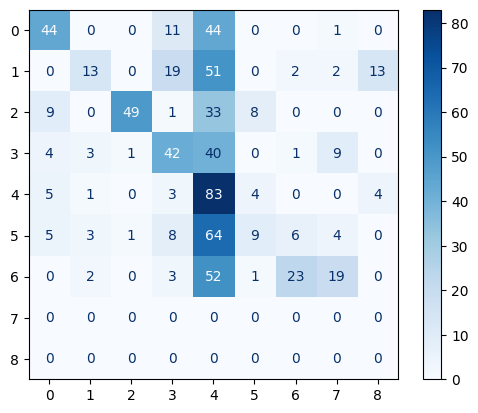

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter

# Create a dictionary to map clusters to the most frequent genre label in each cluster
# cluster_to_label = {}
# for cluster in range(kmeans.n_clusters):
#     # Get the indices of the samples that belong to the current cluster
#     cluster_indices = np.where(kmeans.labels_ == cluster)[0]
    
#     # Get the true labels for those samples
#     true_labels_for_cluster = true_labels_enc[cluster_indices]
    
#     # Find the most frequent true label in the cluster
#     most_common_label = Counter(true_labels_for_cluster).most_common(1)[0][0]
    
#     # Map the cluster label to the most frequent true label
#     cluster_to_label[cluster] = most_common_label

# Create predicted labels that align with true labels based on the cluster-to-label mapping
#aligned_predicted_labels = np.array([cluster_to_label[label] for label in kmeans.labels_])
mapping = greedy_cluster_mapping(true_labels_enc, predicted_labels)
aligned_predicted_labels = np.array([mapping[label] for label in predicted_labels])
# Create the confusion matrix
cm = confusion_matrix(true_labels_enc, aligned_predicted_labels)

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(xticks_rotation='vertical', cmap='Blues')

# Set the title and display the plot
plt.title(f"Confusion Matrix: True Genres vs {algorithm} Clusters with {reduction}")
plt.show()

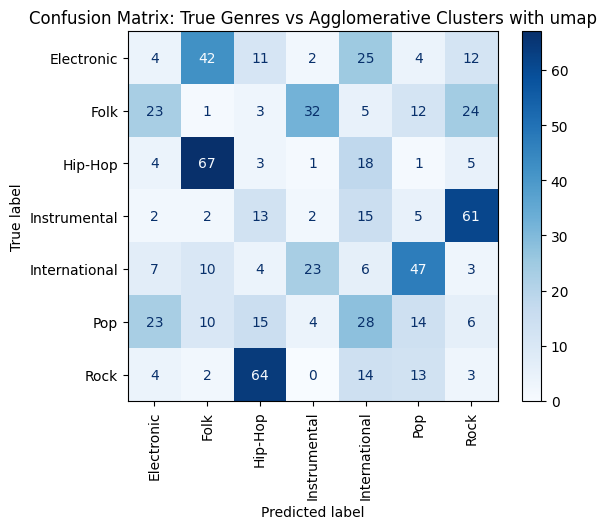

In [69]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter

# Create a dictionary to map clusters to the most frequent genre label in each cluster
cluster_to_label = {}
for cluster in range(kmeans.n_clusters):
    # Get the indices of the samples that belong to the current cluster
    cluster_indices = np.where(kmeans.labels_ == cluster)[0]
    
    # Get the true labels for those samples
    true_labels_for_cluster = true_labels_enc[cluster_indices]
    
    # Find the most frequent true label in the cluster
    most_common_label = Counter(true_labels_for_cluster).most_common(1)[0][0]
    
    # Map the cluster label to the most frequent true label
    cluster_to_label[cluster] = most_common_label

# Create predicted labels that align with true labels based on the cluster-to-label mapping
cm = confusion_matrix(true_labels_enc, kmeans.labels_)

# Solve assignment problem (maximizing matches)
mapping = greedy_cluster_mapping(true_labels_enc, predicted_labels)
aligned_predicted_labels = np.array([mapping[label] for label in predicted_labels])

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(xticks_rotation='vertical', cmap='Blues')

# Set the title and display the plot
plt.title(f"Confusion Matrix: True Genres vs {algorithm} Clusters with {reduction}")
plt.show()

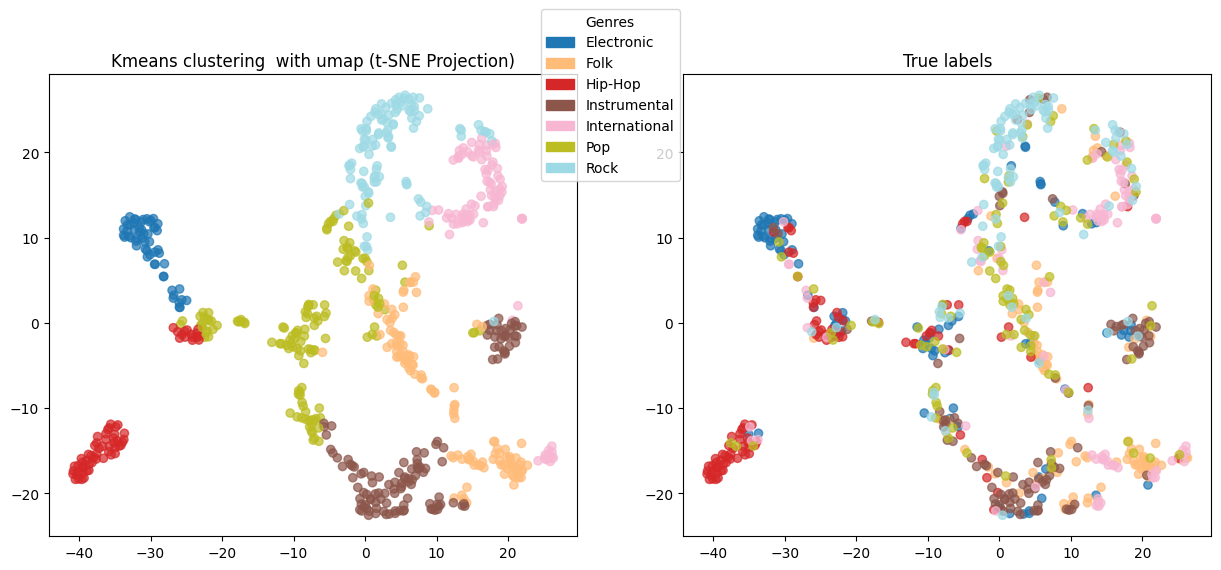

<Figure size 700x600 with 0 Axes>

In [44]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

unique_labels = np.unique(true_labels_enc)
cmap = "tab20"
label2genre = {enc: genre for enc, genre in zip(true_labels_enc, true_labels)}

# Make sure mapping is clean and non-redundant
label2genre = {enc: label2genre[enc] for enc in unique_labels}


X_2d = TSNE(n_components=2, random_state=42).fit_transform(spectrograms_reduced)
fig, axes = plt.subplots(1,2, figsize = (15,6))
plt.figure(figsize=(7, 6))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=aligned_predicted_labels, cmap=cmap, alpha=0.7)
axes[0].set_title(f"{algorithm} clustering  with {reduction} (t-SNE Projection)")
#plt.show()

#lt.figure(figsize=(6, 6))
#plt.scatter(X_2d[:, 0], X_2d[:, 1], c=true_labels_enc, cmap='tab10', alpha=0.7)
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=true_labels_enc, cmap=cmap, alpha=0.7)
handles = [
    mpatches.Patch(color=scatter.cmap(scatter.norm(label)), label=label2genre[label])
    for label in unique_labels
]

fig.legend(handles=handles,  bbox_to_anchor=(0.1, 0.5, 0.45, 0.5), ncol=1, title="Genres")
plt.tight_layout()
axes[1].set_title(f"True labels")
plt.show()